<a href="https://colab.research.google.com/github/MukulGhai/Learning-Probability-Density-Functions-Using-Data/blob/main/Learning_Probability_Density_Functions_Using_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_15292/2879533377.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data.csv", encoding="latin1")
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Columns in dataset:
Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

Transformation Parameters:
a_r = 1.5
b_r = 1.2


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.7557 | G Loss: 0.7123
Epoch 500 | D Loss: 0.7403 | G Loss: 0.6992
Epoch 1000 | D Loss: 0.7412 | G Loss: 0.6974
Epoch 1500 | D Loss: 0.7417 | G Loss: 0.6965
Epoch 2000 | D Loss: 0.7420 | G Loss: 0.6959
Epoch 2500 | D Loss: 0.7420 | G Loss: 0.6956


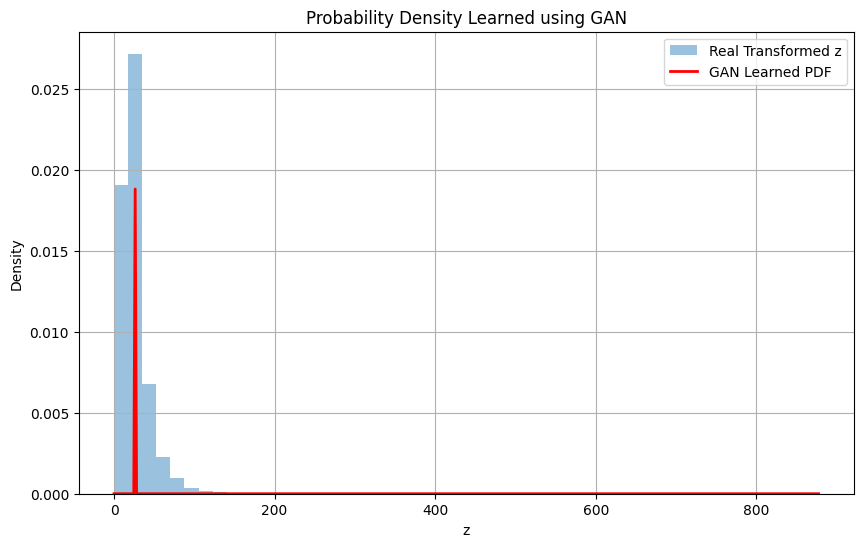


Observations:
1. GAN learns unknown transformed distribution only from samples.
2. KDE on generator samples approximates PDF.
3. More epochs improve mode coverage.
4. GAN training may fluctuate (normal behavior).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import tensorflow as tf
from tensorflow.keras import layers

# ---------------------------
# Load Dataset
# ---------------------------
df = pd.read_csv("/content/data.csv", encoding="latin1")

print("Columns in dataset:")
print(df.columns)

# Find NO2 column safely
col = None
for c in df.columns:
    if "no2" in c.lower():
        col = c
        break

if col is None:
    raise Exception("NO2 column not found")

x = df[col].dropna().astype(float).values.reshape(-1,1)

# ---------------------------
# Step 1: Transformation
# ---------------------------
r = 102303463   # your roll number

ar = 0.5 * (r % 7)
br = 0.3 * ((r % 5) + 1)

print("\nTransformation Parameters:")
print("a_r =", ar)
print("b_r =", br)

z = x + ar * np.sin(br * x)

# Normalize for GAN training
scaler = StandardScaler()
z_scaled = scaler.fit_transform(z)

# ---------------------------
# Build GAN
# ---------------------------
latent_dim = 5

# Generator
generator = tf.keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(latent_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Discriminator
discriminator = tf.keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(1,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Combined GAN
discriminator.trainable = False

gan_input = layers.Input(shape=(latent_dim,))
fake = generator(gan_input)
gan_output = discriminator(fake)

gan = tf.keras.Model(gan_input, gan_output)

gan.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002),
    loss='binary_crossentropy'
)

# ---------------------------
# Training
# ---------------------------
epochs = 3000
batch_size = 64

real = np.ones((batch_size,1))
fake = np.zeros((batch_size,1))

for epoch in range(epochs):

    # Train discriminator
    idx = np.random.randint(0, z_scaled.shape[0], batch_size)
    real_samples = z_scaled[idx]

    noise = np.random.normal(0,1,(batch_size,latent_dim))
    fake_samples = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_samples, real)
    d_loss_fake = discriminator.train_on_batch(fake_samples, fake)

    # Train generator
    noise = np.random.normal(0,1,(batch_size,latent_dim))
    g_loss = gan.train_on_batch(noise, real)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {0.5*(d_loss_real[0]+d_loss_fake[0]):.4f} | G Loss: {g_loss:.4f}")

# ---------------------------
# Step 3: Generate Samples
# ---------------------------
noise = np.random.normal(0,1,(5000,latent_dim))
generated = generator.predict(noise, verbose=0)

# Inverse scaling
generated = scaler.inverse_transform(generated).flatten()
z_real = z.flatten()

# KDE Estimation
kde = gaussian_kde(generated)

x_axis = np.linspace(min(z_real.min(), generated.min()),
                     max(z_real.max(), generated.max()), 500)

pdf_vals = kde(x_axis)

# ---------------------------
# Plot Result
# ---------------------------
plt.figure(figsize=(10,6))

plt.hist(z_real, bins=50, density=True, alpha=0.45, label="Real Transformed z")
plt.plot(x_axis, pdf_vals, color='red', lw=2, label="GAN Learned PDF")

plt.xlabel("z")
plt.ylabel("Density")
plt.title("Probability Density Learned using GAN")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# Observations
# ---------------------------
print("\nObservations:")
print("1. GAN learns unknown transformed distribution only from samples.")
print("2. KDE on generator samples approximates PDF.")
print("3. More epochs improve mode coverage.")
print("4. GAN training may fluctuate (normal behavior).")